# Inspect an accelerating-DM Ly-alpha campaign

This notebook reads a campaign that has already been generated and fitted. It does not run CLASS, SPT, PBS jobs, or nuisance optimization. Quoted minima always refer to sampled points; interpolation is used only for visualization.

In [9]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'lyalpha_pt').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the lyalpha_one_loop project root.')

PROJECT_ROOT = find_project_root()
CAMPAIGN_DIR = PROJECT_ROOT / 'runs/accdm/accdm_validation_v1'
LCDM_ONE_LOOP_CHI2 = 193.105787
ALLOWED_2D_DELTA_CHI2 = 5.991
EXCLUSION_DELTA_CHI2 = 3.841
BOUNDARY_FRACTION = 0.05
SAVE_OUTPUTS = True
OUTPUT_DIR = CAMPAIGN_DIR / 'analysis'

print('Project:', PROJECT_ROOT)
print('Campaign:', CAMPAIGN_DIR)

Project: /home/2/ks405818/Master/lyalpha_one_loop
Campaign: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_validation_v1


## Load completed fits and diagnostics

In [10]:
manifest = pd.read_csv(CAMPAIGN_DIR / 'manifest.csv')
rows = []
nuisance_rows = []
for record in manifest.to_dict(orient='records'):
    point_id = record['point_id']
    theory_file = CAMPAIGN_DIR / 'theory' / f'{point_id}.npz'
    fit_file = CAMPAIGN_DIR / 'fits' / f'{point_id}.json'
    theory_done = CAMPAIGN_DIR / 'status/theory' / f'{point_id}.done.json'
    fit_done = CAMPAIGN_DIR / 'status/fit' / f'{point_id}.done.json'
    row = {
        **record,
        'theory_complete': theory_file.is_file() and theory_done.is_file(),
        'fit_complete': fit_file.is_file() and fit_done.is_file(),
        'chi2_linear': np.nan,
        'chi2_one_loop': np.nan,
        'delta_chi2_loop_minus_linear': np.nan,
        'minimum_bound_distance': np.nan,
        'near_bound_5pct': False,
        'optimizer_success': np.nan,
        'refit_strategy': None,
        'refit_selected_source_point': None,
    }
    if fit_file.is_file():
        payload = json.loads(fit_file.read_text())
        row['refit_strategy'] = payload.get('refit_strategy')
        fits = payload.get('fits', {})
        if 'linear' in fits:
            row['chi2_linear'] = float(fits['linear']['chi2'])
        if 'one_loop' in fits:
            loop = fits['one_loop']
            row['chi2_one_loop'] = float(loop['chi2'])
            row['optimizer_success'] = bool(loop.get('optimizer_success', False))
            selected = loop.get('neighbour_refit_selected_source', {})
            row['refit_selected_source_point'] = selected.get('source_point_id')
            diagnostics = loop.get('boundary_diagnostics', [])
            distances = [float(item['relative_distance_to_nearest_bound']) for item in diagnostics]
            if distances:
                row['minimum_bound_distance'] = min(distances)
                row['near_bound_5pct'] = min(distances) <= BOUNDARY_FRACTION
            for item in diagnostics:
                nuisance_rows.append({
                    'point_id': point_id,
                    'log10m_acc': float(record['log10m_acc']),
                    'log10f_acc': float(record['log10f_acc']),
                    'parameter': item['parameter'],
                    'value': float(item['value']),
                    'lower': float(item['lower']),
                    'upper': float(item['upper']),
                    'relative_distance_to_nearest_bound': float(item['relative_distance_to_nearest_bound']),
                    'within_5pct': float(item['relative_distance_to_nearest_bound']) <= BOUNDARY_FRACTION,
                })
        row['delta_chi2_loop_minus_linear'] = payload.get('delta_chi2_one_loop_minus_linear', np.nan)
    rows.append(row)

results = pd.DataFrame(rows).sort_values('index').reset_index(drop=True)
nuisance = pd.DataFrame(nuisance_rows)
display(results.head())

,index,point_id,active,grid_level,log10m_acc,log10f_acc,m_acc_in_GeV,eta_acc,f_acc,omega_cdm,...,theory_complete,fit_complete,chi2_linear,chi2_one_loop,delta_chi2_loop_minus_linear,minimum_bound_distance,near_bound_5pct,optimizer_success,refit_strategy,refit_selected_source_point
0,0,accdm_logm9_logfm4,1,0,9,-4,1.000000e+09,100.0,0.0001,0.120088,...,True,True,206.269237,192.992074,-13.277164,0.294581,False,True,None,None
1,1,accdm_logm9_logfm2,1,0,9,-2,1.000000e+09,100.0,0.0100,0.118911,...,True,True,213.815370,207.056153,-6.759218,0.332478,False,True,None,None
2,2,accdm_logm9_logfm1,1,0,9,-1,1.000000e+09,100.0,0.1000,0.109182,...,False,False,NaN,NaN,NaN,NaN,False,NaN,None,None
3,3,accdm_logm9_logf0,1,0,9,0,1.000000e+09,100.0,1.0000,0.060050,...,False,False,NaN,NaN,NaN,NaN,False,NaN,None,None
4,4,accdm_logm12_logfm4,1,0,12,-4,1.000000e+12,0.1,0.0001,0.120088,...,True,True,206.220464,193.232799,-12.987665,0.295763,False,True,None,None


## Completion and sampled best fit

In [11]:
status = pd.Series({
    'active points': int(results['active'].astype(bool).sum()),
    'theory complete': int(results['theory_complete'].sum()),
    'fit complete': int(results['fit_complete'].sum()),
})
display(status.to_frame('count'))

completed = results.dropna(subset=['chi2_one_loop']).copy()
if completed.empty:
    raise RuntimeError('No completed one-loop fits are available.')
completed['delta_chi2_from_grid_minimum'] = completed['chi2_one_loop'] - completed['chi2_one_loop'].min()
completed['delta_chi2_vs_lcdm'] = completed['chi2_one_loop'] - LCDM_ONE_LOOP_CHI2
completed['allowed_95pct'] = completed['delta_chi2_from_grid_minimum'] <= ALLOWED_2D_DELTA_CHI2
best = completed.loc[completed['chi2_one_loop'].idxmin()]
columns = [
    'point_id', 'log10m_acc', 'log10f_acc', 'chi2_linear', 'chi2_one_loop',
    'delta_chi2_loop_minus_linear', 'delta_chi2_vs_lcdm',
    'minimum_bound_distance', 'near_bound_5pct', 'optimizer_success',
]
display(completed.nsmallest(20, 'chi2_one_loop')[columns])
print(f"Grid minimum: {best['point_id']}")
print(f"chi2_one_loop = {best['chi2_one_loop']:.6f}")
print(f"Delta chi2 versus LCDM = {best['delta_chi2_vs_lcdm']:+.6f}")

,count
active points,16
theory complete,13
fit complete,13


,point_id,log10m_acc,log10f_acc,chi2_linear,chi2_one_loop,delta_chi2_loop_minus_linear,delta_chi2_vs_lcdm,minimum_bound_distance,near_bound_5pct,optimizer_success
14,accdm_logm18_logfm1,18,-1,207.028149,192.566262,-14.461887,-0.539525,0.180766,False,True
13,accdm_logm18_logfm2,18,-2,206.170722,192.892634,-13.278088,-0.213153,0.284334,False,True
0,accdm_logm9_logfm4,9,-4,206.269237,192.992074,-13.277164,-0.113713,0.294581,False,True
9,accdm_logm15_logfm2,15,-2,206.295821,193.146424,-13.149397,0.040637,0.295211,False,True
12,accdm_logm18_logfm4,18,-4,206.215844,193.228869,-12.986975,0.123082,0.295753,False,True
8,accdm_logm15_logfm4,15,-4,206.217199,193.231130,-12.986069,0.125343,0.295763,False,True
4,accdm_logm12_logfm4,12,-4,206.220464,193.232799,-12.987665,0.127012,0.295763,False,True
5,accdm_logm12_logfm2,12,-2,206.611312,193.282413,-13.328899,0.176626,0.294890,False,True
6,accdm_logm12_logfm1,12,-1,211.691847,194.765288,-16.926558,1.659501,0.284024,False,True
10,accdm_logm15_logfm1,15,-1,209.305650,197.851389,-11.454261,4.745602,0.290291,False,True


Grid minimum: accdm_logm18_logfm1
chi2_one_loop = 192.566262
Delta chi2 versus LCDM = -0.539525


## Sampled likelihood and one-loop improvement

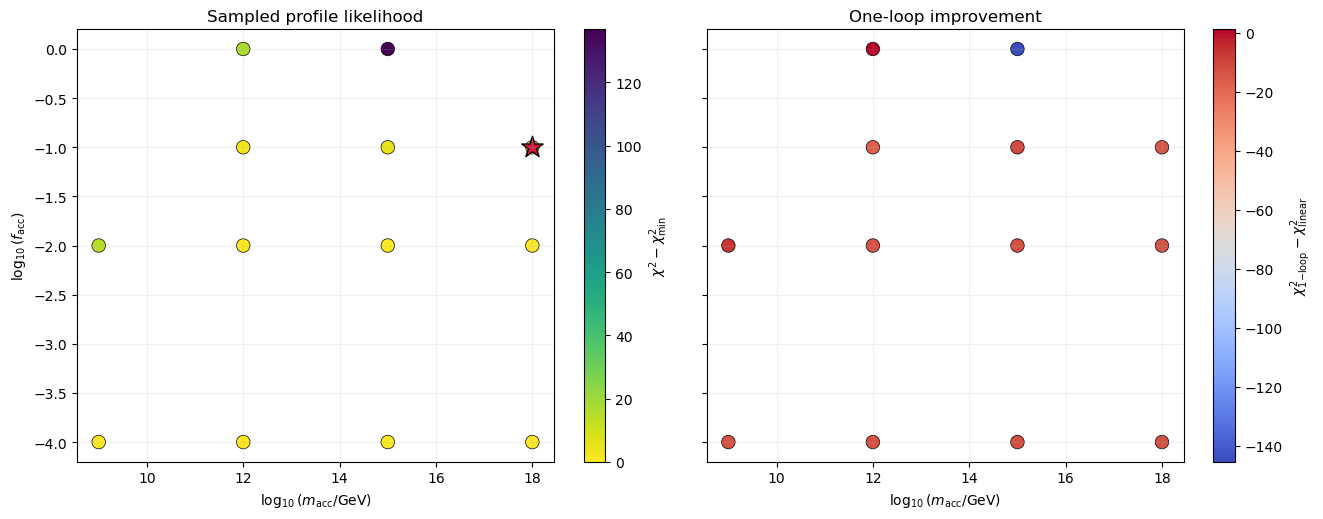

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.3), sharex=True, sharey=True)
delta_scatter = axes[0].scatter(
    completed['log10m_acc'], completed['log10f_acc'],
    c=completed['delta_chi2_from_grid_minimum'], cmap='viridis_r',
    s=95, edgecolor='black', linewidth=0.5,
)
fig.colorbar(delta_scatter, ax=axes[0], label=r'$\chi^2-\chi^2_{\min}$')
axes[0].scatter([best['log10m_acc']], [best['log10f_acc']], marker='*', s=260, color='crimson', edgecolor='black')
axes[0].set_title('Sampled profile likelihood')

improvement_scatter = axes[1].scatter(
    completed['log10m_acc'], completed['log10f_acc'],
    c=completed['delta_chi2_loop_minus_linear'], cmap='coolwarm',
    s=95, edgecolor='black', linewidth=0.5,
)
fig.colorbar(improvement_scatter, ax=axes[1], label=r'$\chi^2_{1\mathrm{-loop}}-\chi^2_{\mathrm{linear}}$')
axes[1].set_title('One-loop improvement')
for ax in axes:
    ax.set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
    ax.grid(alpha=0.2)
axes[0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
fig.tight_layout()
plt.show()

## Interpolated paper-style maps

This cell requires a complete rectangular grid. Linear interpolation does not create additional likelihood evaluations.

In [13]:
x_grid = np.sort(completed['log10m_acc'].unique())
y_grid = np.sort(completed['log10f_acc'].unique())

def regular_grid(column):
    table = completed.pivot(index='log10f_acc', columns='log10m_acc', values=column).reindex(index=y_grid, columns=x_grid)
    values = table.to_numpy(dtype=float)
    if values.shape != (len(y_grid), len(x_grid)) or not np.isfinite(values).all():
        raise RuntimeError(f'Incomplete rectangular grid for {column}.')
    return values

def interpolate(values, nx=500, ny=400):
    x_dense = np.linspace(x_grid.min(), x_grid.max(), nx)
    y_dense = np.linspace(y_grid.min(), y_grid.max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)
    function = RegularGridInterpolator((y_grid, x_grid), values, method='linear', bounds_error=False)
    zz = function(np.column_stack([yy.ravel(), xx.ravel()])).reshape(xx.shape)
    return x_dense, y_dense, zz

delta_min_grid = regular_grid('delta_chi2_from_grid_minimum')
delta_lcdm_grid = regular_grid('delta_chi2_vs_lcdm')
x_dense, y_dense, delta_min_dense = interpolate(delta_min_grid)
_, _, delta_lcdm_dense = interpolate(delta_lcdm_grid)

fig_maps, axes = plt.subplots(1, 2, figsize=(14.2, 5.5), sharex=True, sharey=True)
left = axes[0].contourf(x_dense, y_dense, np.clip(delta_min_dense, 0, ALLOWED_2D_DELTA_CHI2), levels=np.linspace(0, ALLOWED_2D_DELTA_CHI2, 13), cmap='YlGnBu')
axes[0].contour(x_dense, y_dense, delta_min_dense, levels=[ALLOWED_2D_DELTA_CHI2], colors='navy', linewidths=2)
fig_maps.colorbar(left, ax=axes[0], label=r'$\chi^2-\chi^2_{\min}$')
axes[0].set_title(r'95% region: $\Delta\chi^2\leq5.991$')

right = axes[1].contourf(x_dense, y_dense, np.clip(delta_lcdm_dense, -4, 12), levels=np.linspace(-4, 12, 17), cmap='RdYlBu_r', extend='both')
axes[1].contour(x_dense, y_dense, delta_lcdm_dense, levels=[EXCLUSION_DELTA_CHI2], colors='navy', linewidths=2)
axes[1].contourf(x_dense, y_dense, delta_lcdm_dense, levels=[EXCLUSION_DELTA_CHI2, np.nanmax(delta_lcdm_dense)+1], colors='none', hatches=['///'])
fig_maps.colorbar(right, ax=axes[1], label=r'$\chi^2-\chi^2_{\Lambda\mathrm{CDM}}$')
axes[1].set_title(r'Exclusion relative to $\Lambda$CDM: 3.841')
for ax in axes:
    ax.scatter(completed['log10m_acc'], completed['log10f_acc'], s=7, color='black', alpha=0.25)
    ax.scatter([best['log10m_acc']], [best['log10f_acc']], marker='*', s=220, color='black', edgecolor='white')
    ax.set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
axes[0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
fig_maps.tight_layout()
plt.show()

RuntimeError: Incomplete rectangular grid for delta_chi2_from_grid_minimum.

## Nuisance-bound audit

In [14]:
best_fit_path = CAMPAIGN_DIR / 'fits' / f"{best['point_id']}.json"
best_payload = json.loads(best_fit_path.read_text())
best_boundaries = pd.DataFrame(best_payload['fits']['one_loop'].get('boundary_diagnostics', []))
best_boundaries['distance_percent'] = 100 * best_boundaries['relative_distance_to_nearest_bound']
best_boundaries['within_5pct'] = best_boundaries['relative_distance_to_nearest_bound'] <= BOUNDARY_FRACTION
display(best_boundaries.sort_values('distance_percent'))

if nuisance.empty:
    boundary_summary = pd.DataFrame()
else:
    likelihood = completed[['point_id', 'allowed_95pct', 'chi2_one_loop']]
    nuisance_audit = nuisance.merge(likelihood, on='point_id', how='left')
    boundary_summary = nuisance_audit.groupby('parameter').agg(
        grid_points=('point_id', 'nunique'),
        points_within_5pct=('within_5pct', 'sum'),
        minimum_distance=('relative_distance_to_nearest_bound', 'min'),
    ).sort_values('minimum_distance')
    display(boundary_summary)
    warnings = nuisance_audit[nuisance_audit['allowed_95pct'] & nuisance_audit['within_5pct']]
    print('Five-percent warnings inside the sampled 95% region:', len(warnings))
    display(warnings.sort_values('relative_distance_to_nearest_bound').head(50))

,lower,near_bound,parameter,relative_distance_to_nearest_bound,upper,value,distance_percent,within_5pct
5,-1000.000000,False,beta_ct,0.180766,1000.000000,638.467407,18.076630,False
2,-8.000000,False,alpha_bias,0.281900,8.000000,-3.489596,28.190028,False
0,-11.512925,False,log_alpha_F,0.434367,0.693147,-4.608764,43.436670,False
3,-15.000000,False,beta_bias,0.463207,20.000000,1.212258,46.320737,False
1,-10.000000,False,beta_F,0.496710,20.000000,5.098691,49.671029,False
4,-1000.000000,False,alpha_ct,0.499985,1000.000000,-0.030115,49.998494,False


,grid_points,points_within_5pct,minimum_distance
parameter,,,
beta_bias,13,0,0.101559
beta_ct,13,0,0.180766
alpha_bias,13,0,0.281900
log_alpha_F,13,0,0.297698
beta_F,13,0,0.413046
alpha_ct,13,0,0.499768


Five-percent warnings inside the sampled 95% region: 0


,point_id,log10m_acc,log10f_acc,parameter,value,lower,upper,relative_distance_to_nearest_bound,within_5pct,allowed_95pct,chi2_one_loop


## Save analysis products

In [16]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    completed.to_csv(OUTPUT_DIR / 'campaign_profile_likelihood.csv', index=False)
    nuisance.to_csv(OUTPUT_DIR / 'nuisance_boundary_diagnostics.csv', index=False)
    boundary_summary.to_csv(OUTPUT_DIR / 'nuisance_boundary_summary.csv')
    summary = {
        'point_id': best['point_id'],
        'log10m_acc': float(best['log10m_acc']),
        'log10f_acc': float(best['log10f_acc']),
        'chi2_one_loop': float(best['chi2_one_loop']),
        'lcdm_reference_chi2': LCDM_ONE_LOOP_CHI2,
        'delta_chi2_vs_lcdm': float(best['delta_chi2_vs_lcdm']),
        'minimum_nuisance_bound_distance': float(best['minimum_bound_distance']),
        'any_nuisance_within_5pct': bool(best['near_bound_5pct']),
    }
    (OUTPUT_DIR / 'best_fit_summary.json').write_text(json.dumps(summary, indent=2, sort_keys=True) + '\n')
    fig.savefig(OUTPUT_DIR / 'sampled_likelihood_and_loop_improvement.png', dpi=220, bbox_inches='tight')
    # fig_maps.savefig(OUTPUT_DIR / 'accdm_profile_likelihood_maps.png', dpi=220, bbox_inches='tight')
    print('Saved:', OUTPUT_DIR)

Saved: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_validation_v1/analysis


## Interpretation

Use the discrete grid minimum for numerical statements. Treat interpolated contours only as a visualization. Any point inside the 95% region that lies within five percent of a nuisance bound must be refitted with a wider numerical box before the final map is accepted. Production/precision agreement and momentum-quadrature convergence remain separate acceptance checks.